In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Libraries imported successfully")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully
Pandas version: 2.2.2


In [3]:
#Load dataset
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset loaded successfully")
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset loaded successfully
Shape: 7,043 rows, 21 columns
Memory usage: 6.82 MB


In [5]:
#Initial inspection
print("First 5 rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nColumn names:")
print(df.columns.tolist())

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No      

In [7]:
#Basic statistics
print("Numerical columns summary:")
print(df.describe())

print("\nCategorical columns:")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Found {len(categorical_cols)} categorical columns")
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")

Numerical columns summary:
       SeniorCitizen  tenure  MonthlyCharges
count        7043.00 7043.00         7043.00
mean            0.16   32.37           64.76
std             0.37   24.56           30.09
min             0.00    0.00           18.25
25%             0.00    9.00           35.50
50%             0.00   29.00           70.35
75%             0.00   55.00           89.85
max             1.00   72.00          118.75

Categorical columns:
Found 18 categorical columns

customerID: 7043 unique values

gender: 2 unique values

Partner: 2 unique values

Dependents: 2 unique values

PhoneService: 2 unique values

MultipleLines: 3 unique values

InternetService: 3 unique values

OnlineSecurity: 3 unique values

OnlineBackup: 3 unique values

DeviceProtection: 3 unique values

TechSupport: 3 unique values

StreamingTV: 3 unique values

StreamingMovies: 3 unique values

Contract: 3 unique values

PaperlessBilling: 2 unique values

PaymentMethod: 4 unique values

TotalCharges: 6531 u

In [9]:
#Check target variable
print("Churn Distribution")

churn_counts = df['Churn'].value_counts()
print("\nCounts:")
print(churn_counts)

churn_pct = df['Churn'].value_counts(normalize=True) * 100
print("\nPercentages:")
print(f"Retained (No): {churn_pct['No']:.2f}%")
print(f"Churned (Yes): {churn_pct['Yes']:.2f}%")

print(f"\nTotal customers: {len(df):,}")
print(f"Churned customers: {(df['Churn']=='Yes').sum():,}")
print(f"Retained customers: {(df['Churn']=='No').sum():,}")

Churn Distribution

Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentages:
Retained (No): 73.46%
Churned (Yes): 26.54%

Total customers: 7,043
Churned customers: 1,869
Retained customers: 5,174


In [11]:
#Check for missing values
print("Missing Values Check")

missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values found")
else:
    missing = missing[missing > 0].sort_values(ascending=False)
    for col, count in missing.items():
        pct = (count / len(df)) * 100
        print(f"{col}: {count:,} ({pct:.2f}%)")

print("\nDuplicate rows:")
duplicates = df.duplicated().sum()
print(f"{duplicates} duplicate rows found")

Missing Values Check
No missing values found

Duplicate rows:
0 duplicate rows found


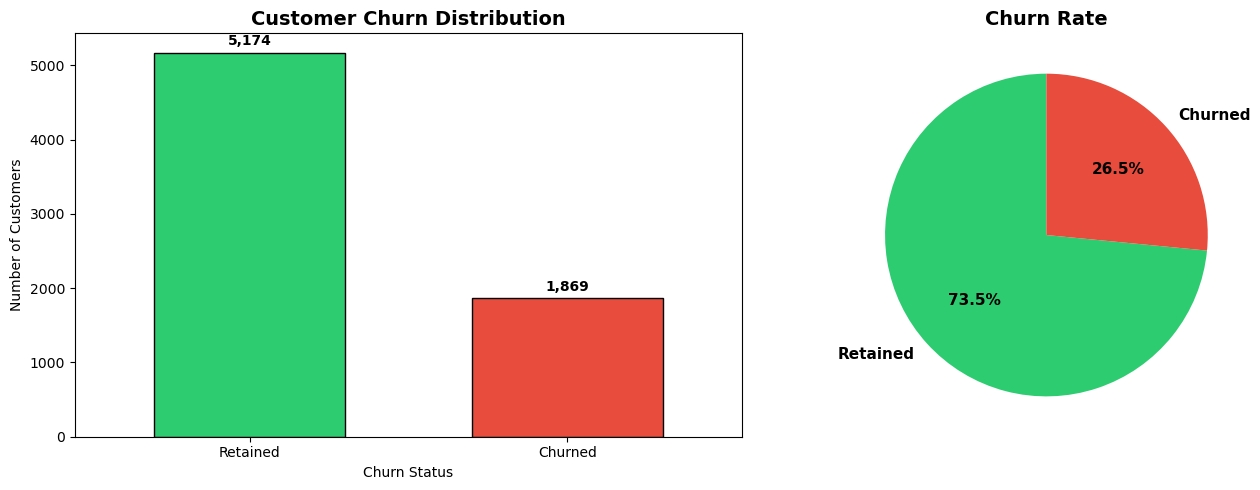

Visualization saved: images/01_churn_distribution.png


In [13]:
#Visualize churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
colors = ['#2ecc71', '#e74c3c']
churn_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', width=0.6)
axes[0].set_title('Customer Churn Distribution', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(['Retained', 'Churned'], rotation=0)

for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'], 
           autopct='%1.1f%%', colors=colors, startangle=90,
           textprops={'fontweight': 'bold', 'fontsize': 11})
axes[1].set_title('Churn Rate', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('images/01_churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved: images/01_churn_distribution.png")

In [15]:
#Analyze customer demographics
print("CUSTOMER DEMOGRAPHICS ANALYSIS")

demographics = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

for col in demographics:
    if col in df.columns:
        print(f"\n{col}:")
        churn_by_demo = df.groupby(col)['Churn'].value_counts(normalize=True).unstack()
        churn_by_demo['Churn_Rate'] = churn_by_demo['Yes'] * 100
        print(churn_by_demo[['Yes', 'No', 'Churn_Rate']].round(2))

CUSTOMER DEMOGRAPHICS ANALYSIS

gender:
Churn   Yes   No  Churn_Rate
gender                      
Female 0.27 0.73       26.92
Male   0.26 0.74       26.16

SeniorCitizen:
Churn          Yes   No  Churn_Rate
SeniorCitizen                      
0             0.24 0.76       23.61
1             0.42 0.58       41.68

Partner:
Churn    Yes   No  Churn_Rate
Partner                      
No      0.33 0.67       32.96
Yes     0.20 0.80       19.66

Dependents:
Churn       Yes   No  Churn_Rate
Dependents                      
No         0.31 0.69       31.28
Yes        0.15 0.85       15.45


In [17]:
#Analyze service subscriptions
print("SERVICE SUBSCRIPTION ANALYSIS")

services = ['PhoneService', 'MultipleLines', 'InternetService', 
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']

service_churn = {}

for service in services:
    if service in df.columns:
        churn_rate = df.groupby(service)['Churn'].apply(
            lambda x: (x == 'Yes').sum() / len(x) * 100
        )
        service_churn[service] = churn_rate

print("\nChurn Rate by Service:")
for service, rates in service_churn.items():
    print(f"\n{service}:")
    print(rates.sort_values(ascending=False))

SERVICE SUBSCRIPTION ANALYSIS

Churn Rate by Service:

PhoneService:
PhoneService
Yes   26.71
No    24.93
Name: Churn, dtype: float64

MultipleLines:
MultipleLines
Yes                28.61
No                 25.04
No phone service   24.93
Name: Churn, dtype: float64

InternetService:
InternetService
Fiber optic   41.89
DSL           18.96
No             7.40
Name: Churn, dtype: float64

OnlineSecurity:
OnlineSecurity
No                    41.77
Yes                   14.61
No internet service    7.40
Name: Churn, dtype: float64

OnlineBackup:
OnlineBackup
No                    39.93
Yes                   21.53
No internet service    7.40
Name: Churn, dtype: float64

DeviceProtection:
DeviceProtection
No                    39.13
Yes                   22.50
No internet service    7.40
Name: Churn, dtype: float64

TechSupport:
TechSupport
No                    41.64
Yes                   15.17
No internet service    7.40
Name: Churn, dtype: float64

StreamingTV:
StreamingTV
No             

In [19]:
#Analyze contract and payment
print("CONTRACT & PAYMENT ANALYSIS")

contract_cols = ['Contract', 'PaymentMethod', 'PaperlessBilling']

for col in contract_cols:
    if col in df.columns:
        print(f"\n{col}:")
        churn_by_contract = df.groupby(col)['Churn'].value_counts()
        total_by_contract = df.groupby(col).size()
        churn_rate = (churn_by_contract.xs('Yes', level=1) / total_by_contract * 100).sort_values(ascending=False)
        print(churn_rate)

CONTRACT & PAYMENT ANALYSIS

Contract:
Contract
Month-to-month   42.71
One year         11.27
Two year          2.83
dtype: float64

PaymentMethod:
PaymentMethod
Electronic check            45.29
Mailed check                19.11
Bank transfer (automatic)   16.71
Credit card (automatic)     15.24
dtype: float64

PaperlessBilling:
PaperlessBilling
Yes   33.57
No    16.33
dtype: float64


In [21]:
#Tenure analysis
print("CUSTOMER TENURE ANALYSIS")

print("\nTenure statistics:")
print(df['tenure'].describe())

print("\nTenure by churn status:")
print(df.groupby('Churn')['tenure'].describe())

print("\nAverage tenure:")
print(f"Churned customers: {df[df['Churn']=='Yes']['tenure'].mean():.1f} months")
print(f"Retained customers: {df[df['Churn']=='No']['tenure'].mean():.1f} months")
print(f"Difference: {df[df['Churn']=='No']['tenure'].mean() - df[df['Churn']=='Yes']['tenure'].mean():.1f} months")

# Create tenure groups
df['tenure_group'] = pd.cut(df['tenure'], 
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-12 months', '12-24 months', '24-48 months', '48-72 months'])

print("\nChurn rate by tenure group:")
tenure_churn = df.groupby('tenure_group')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
print(tenure_churn)

CUSTOMER TENURE ANALYSIS

Tenure statistics:
count   7043.00
mean      32.37
std       24.56
min        0.00
25%        9.00
50%       29.00
75%       55.00
max       72.00
Name: tenure, dtype: float64

Tenure by churn status:
        count  mean   std  min   25%   50%   75%   max
Churn                                                 
No    5174.00 37.57 24.11 0.00 15.00 38.00 61.00 72.00
Yes   1869.00 17.98 19.53 1.00  2.00 10.00 29.00 72.00

Average tenure:
Churned customers: 18.0 months
Retained customers: 37.6 months
Difference: 19.6 months

Churn rate by tenure group:
tenure_group
0-12 months    47.68
12-24 months   28.71
24-48 months   20.39
48-72 months    9.51
Name: Churn, dtype: float64


In [23]:
#Revenue analysis
print("REVENUE ANALYSIS")

# Fix TotalCharges if needed (sometimes has spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill any NaN with 0
df['TotalCharges'].fillna(0, inplace=True)

print("\nMonthly Charges:")
print(df['MonthlyCharges'].describe())

print("\nTotal Charges:")
print(df['TotalCharges'].describe())

print("\nRevenue by churn status:")
print(f"\nChurned customers:")
print(f"  Avg Monthly Charges: ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"  Avg Total Charges: ${df[df['Churn']=='Yes']['TotalCharges'].mean():.2f}")

print(f"\nRetained customers:")
print(f"  Avg Monthly Charges: ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")
print(f"  Avg Total Charges: ${df[df['Churn']=='No']['TotalCharges'].mean():.2f}")

# Calculate revenue at risk
churned_monthly_revenue = df[df['Churn']=='Yes']['MonthlyCharges'].sum()
total_monthly_revenue = df['MonthlyCharges'].sum()

print(f"\nRevenue Impact:")
print(f"  Total monthly revenue: ${total_monthly_revenue:,.2f}")
print(f"  Lost monthly revenue (churned): ${churned_monthly_revenue:,.2f}")
print(f"  Revenue at risk: {churned_monthly_revenue/total_monthly_revenue*100:.1f}%")

REVENUE ANALYSIS

Monthly Charges:
count   7043.00
mean      64.76
std       30.09
min       18.25
25%       35.50
50%       70.35
75%       89.85
max      118.75
Name: MonthlyCharges, dtype: float64

Total Charges:
count   7043.00
mean    2279.73
std     2266.79
min        0.00
25%      398.55
50%     1394.55
75%     3786.60
max     8684.80
Name: TotalCharges, dtype: float64

Revenue by churn status:

Churned customers:
  Avg Monthly Charges: $74.44
  Avg Total Charges: $1531.80

Retained customers:
  Avg Monthly Charges: $61.27
  Avg Total Charges: $2549.91

Revenue Impact:
  Total monthly revenue: $456,116.60
  Lost monthly revenue (churned): $139,130.85
  Revenue at risk: 30.5%


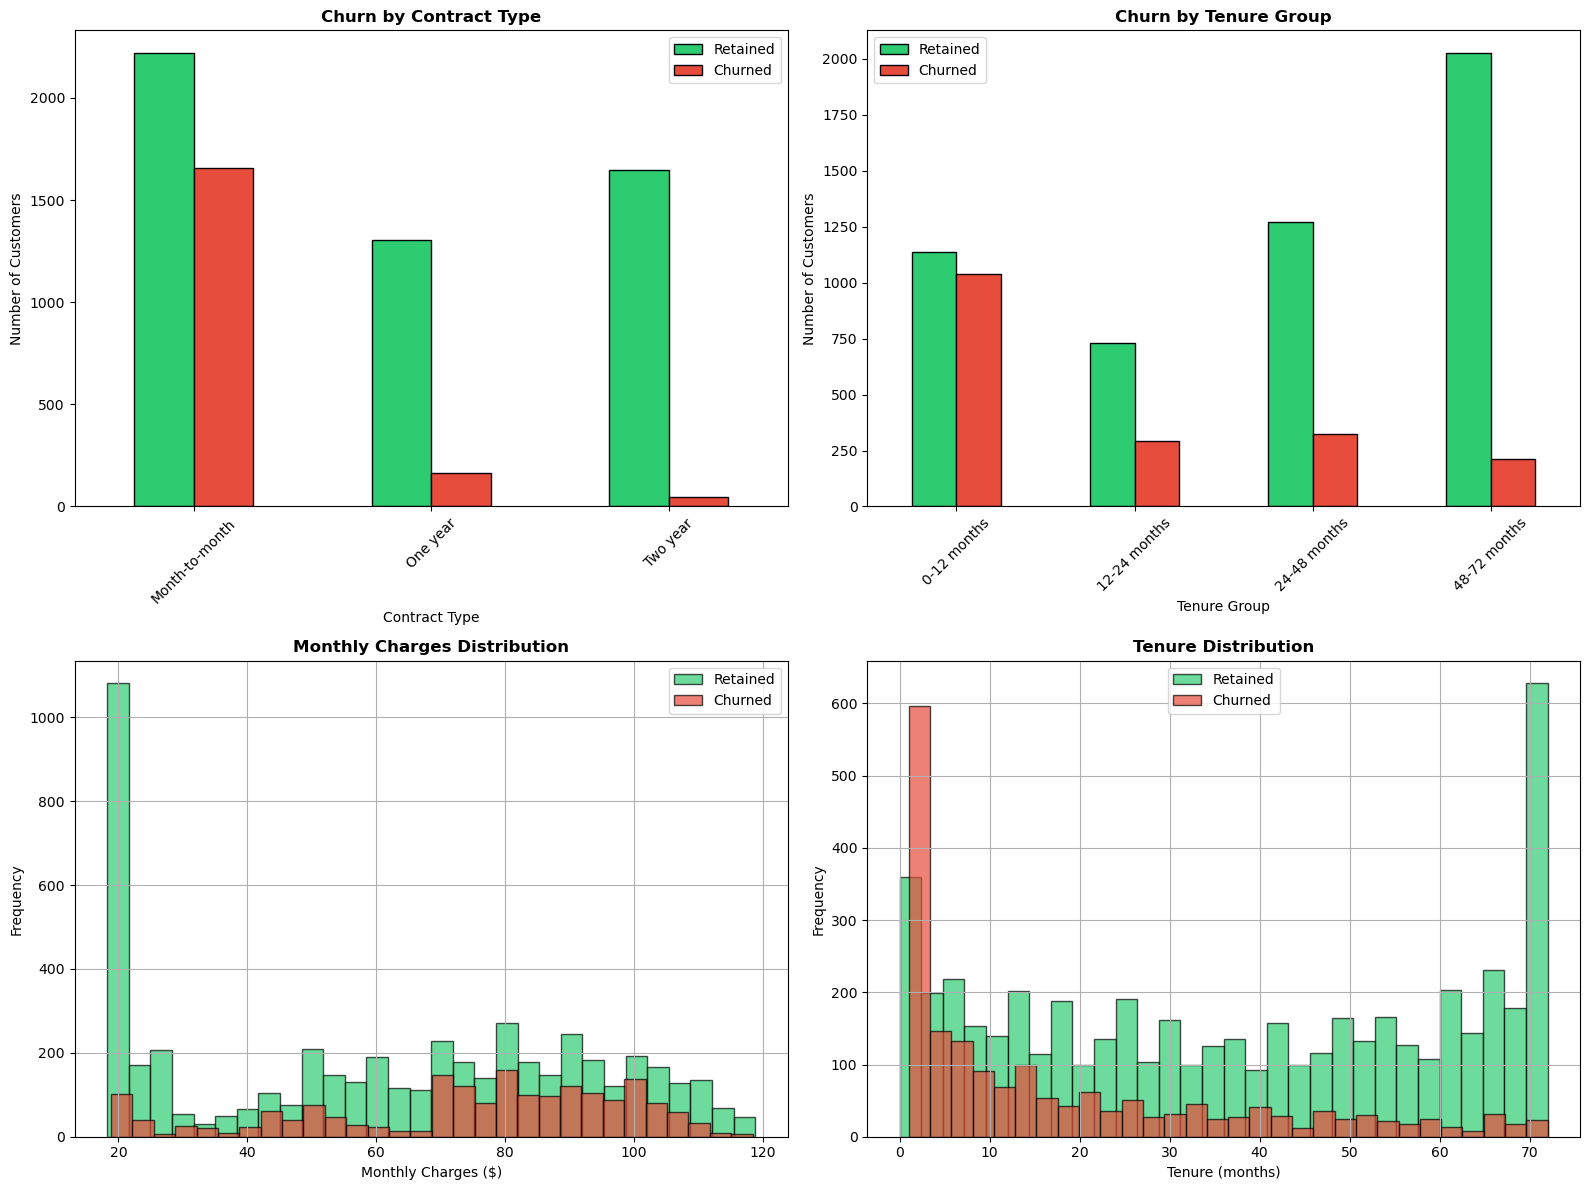

Visualization saved: images/02_customer_analysis.png


In [25]:
#Visualize key insights
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Churn by Contract Type
contract_churn = df.groupby('Contract')['Churn'].value_counts().unstack()
contract_churn.plot(kind='bar', ax=axes[0, 0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0, 0].set_title('Churn by Contract Type', fontweight='bold')
axes[0, 0].set_xlabel('Contract Type')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].legend(['Retained', 'Churned'])
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45)

# Plot 2: Churn by Tenure Group
tenure_data = df.groupby('tenure_group')['Churn'].value_counts().unstack()
tenure_data.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0, 1].set_title('Churn by Tenure Group', fontweight='bold')
axes[0, 1].set_xlabel('Tenure Group')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].legend(['Retained', 'Churned'])
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)

# Plot 3: Monthly Charges Distribution
df[df['Churn']=='No']['MonthlyCharges'].hist(ax=axes[1, 0], bins=30, 
                                              color='#2ecc71', alpha=0.7, edgecolor='black', label='Retained')
df[df['Churn']=='Yes']['MonthlyCharges'].hist(ax=axes[1, 0], bins=30,
                                               color='#e74c3c', alpha=0.7, edgecolor='black', label='Churned')
axes[1, 0].set_title('Monthly Charges Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Monthly Charges ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Plot 4: Tenure Distribution
df[df['Churn']=='No']['tenure'].hist(ax=axes[1, 1], bins=30,
                                      color='#2ecc71', alpha=0.7, edgecolor='black', label='Retained')
df[df['Churn']=='Yes']['tenure'].hist(ax=axes[1, 1], bins=30,
                                       color='#e74c3c', alpha=0.7, edgecolor='black', label='Churned')
axes[1, 1].set_title('Tenure Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Tenure (months)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('images/02_customer_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved: images/02_customer_analysis.png")

In [27]:
#Calculate Customer Lifetime Value (CLV)
print("CUSTOMER LIFETIME VALUE ANALYSIS")

# CLV = Monthly Charges × Average Customer Lifespan
# For telecom, we'll use tenure as a proxy for lifespan

df['CLV'] = df['MonthlyCharges'] * df['tenure']

print("\nCLV Statistics:")
print(df['CLV'].describe())

print("\nCLV by Churn Status:")
print(df.groupby('Churn')['CLV'].describe())

print("\nAverage CLV:")
churned_clv = df[df['Churn']=='Yes']['CLV'].mean()
retained_clv = df[df['Churn']=='No']['CLV'].mean()
print(f"Churned customers: ${churned_clv:,.2f}")
print(f"Retained customers: ${retained_clv:,.2f}")
print(f"Difference: ${retained_clv - churned_clv:,.2f}")

# Total CLV at risk
total_clv_at_risk = df[df['Churn']=='Yes']['CLV'].sum()
print(f"\nTotal CLV lost to churn: ${total_clv_at_risk:,.2f}")

CUSTOMER LIFETIME VALUE ANALYSIS

CLV Statistics:
count   7043.00
mean    2279.58
std     2264.73
min        0.00
25%      394.00
50%     1393.60
75%     3786.10
max     8550.00
Name: CLV, dtype: float64

CLV by Churn Status:
        count    mean     std   min    25%     50%     75%     max
Churn                                                             
No    5174.00 2549.77 2328.40  0.00 574.56 1687.12 4244.81 8550.00
Yes   1869.00 1531.61 1886.77 18.85 137.90  700.00 2334.80 8481.60

Average CLV:
Churned customers: $1,531.61
Retained customers: $2,549.77
Difference: $1,018.16

Total CLV lost to churn: $2,862,576.90


In [29]:
#RFM Segmentation (Modified for Telecom)
print("RFM-STYLE CUSTOMER SEGMENTATION")

# For telecom, we adapt RFM to:
# R = Recency (tenure - higher is better, meaning long-time customer)
# F = Frequency (number of services - proxy for engagement)
# M = Monetary (MonthlyCharges)

# Calculate number of services
service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity', 
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

df['num_services'] = 0
for col in service_cols:
    df['num_services'] += (df[col] == 'Yes').astype(int)

print(f"Average services per customer: {df['num_services'].mean():.2f}")

# Create RFM scores (1-4 scale, 4 is best)
df['R_score'] = pd.qcut(df['tenure'], q=4, labels=[1, 2, 3, 4])
df['F_score'] = pd.qcut(df['num_services'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
df['M_score'] = pd.qcut(df['MonthlyCharges'], q=4, labels=[1, 2, 3, 4])

# Combine into RFM segment
df['RFM_Score'] = df['R_score'].astype(str) + df['F_score'].astype(str) + df['M_score'].astype(str)
df['RFM_Total'] = df['R_score'].astype(int) + df['F_score'].astype(int) + df['M_score'].astype(int)

# Create customer segments
def segment_customers(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal'
    elif score >= 6:
        return 'Potential'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

df['Customer_Segment'] = df['RFM_Total'].apply(segment_customers)

print("\nCustomer Segments:")
print(df['Customer_Segment'].value_counts())

print("\nChurn Rate by Segment:")
segment_churn = df.groupby('Customer_Segment')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False)
print(segment_churn)

print("\nAverage CLV by Segment:")
segment_clv = df.groupby('Customer_Segment')['CLV'].mean().sort_values(ascending=False)
print(segment_clv)

RFM-STYLE CUSTOMER SEGMENTATION
Average services per customer: 2.94

Customer Segments:
Customer_Segment
Champions    1952
Potential    1785
At Risk      1517
Loyal        1377
Lost          412
Name: count, dtype: int64

Churn Rate by Segment:
Customer_Segment
Potential   31.65
Loyal       31.45
At Risk     27.03
Lost        26.70
Champions   17.98
Name: Churn, dtype: float64

Average CLV by Segment:
Customer_Segment
Champions   5279.25
Loyal       2360.49
Potential   1036.30
At Risk      408.78
Lost          72.06
Name: CLV, dtype: float64


In [31]:
#Cohort Analysis
print("COHORT RETENTION ANALYSIS")

# Create cohorts based on tenure ranges
cohort_labels = {
    '0-6 months': (0, 6),
    '6-12 months': (6, 12),
    '12-24 months': (12, 24),
    '24-36 months': (24, 36),
    '36-48 months': (36, 48),
    '48+ months': (48, 72)
}

cohort_analysis = []

for label, (min_tenure, max_tenure) in cohort_labels.items():
    cohort_df = df[(df['tenure'] > min_tenure) & (df['tenure'] <= max_tenure)]
    
    total_customers = len(cohort_df)
    churned = (cohort_df['Churn'] == 'Yes').sum()
    retained = total_customers - churned
    churn_rate = (churned / total_customers * 100) if total_customers > 0 else 0
    retention_rate = 100 - churn_rate
    avg_revenue = cohort_df['MonthlyCharges'].mean()
    
    cohort_analysis.append({
        'Cohort': label,
        'Total_Customers': total_customers,
        'Retained': retained,
        'Churned': churned,
        'Retention_Rate': retention_rate,
        'Churn_Rate': churn_rate,
        'Avg_Monthly_Revenue': avg_revenue
    })

cohort_df = pd.DataFrame(cohort_analysis)
print("\nCohort Analysis:")
print(cohort_df.to_string(index=False))

# Save cohort analysis
cohort_df.to_csv('analysis/cohort_analysis.csv', index=False)
print("\nCohort analysis saved to: analysis/cohort_analysis.csv")

COHORT RETENTION ANALYSIS

Cohort Analysis:
      Cohort  Total_Customers  Retained  Churned  Retention_Rate  Churn_Rate  Avg_Monthly_Revenue
  0-6 months             1470       686      784           46.67       53.33                54.84
 6-12 months              705       452      253           64.11       35.89                58.95
12-24 months             1024       730      294           71.29       28.71                61.36
24-36 months              832       652      180           78.37       21.63                65.58
36-48 months              762       617      145           80.97       19.03                66.32
  48+ months             2239      2026      213           90.49        9.51                73.95

Cohort analysis saved to: analysis/cohort_analysis.csv


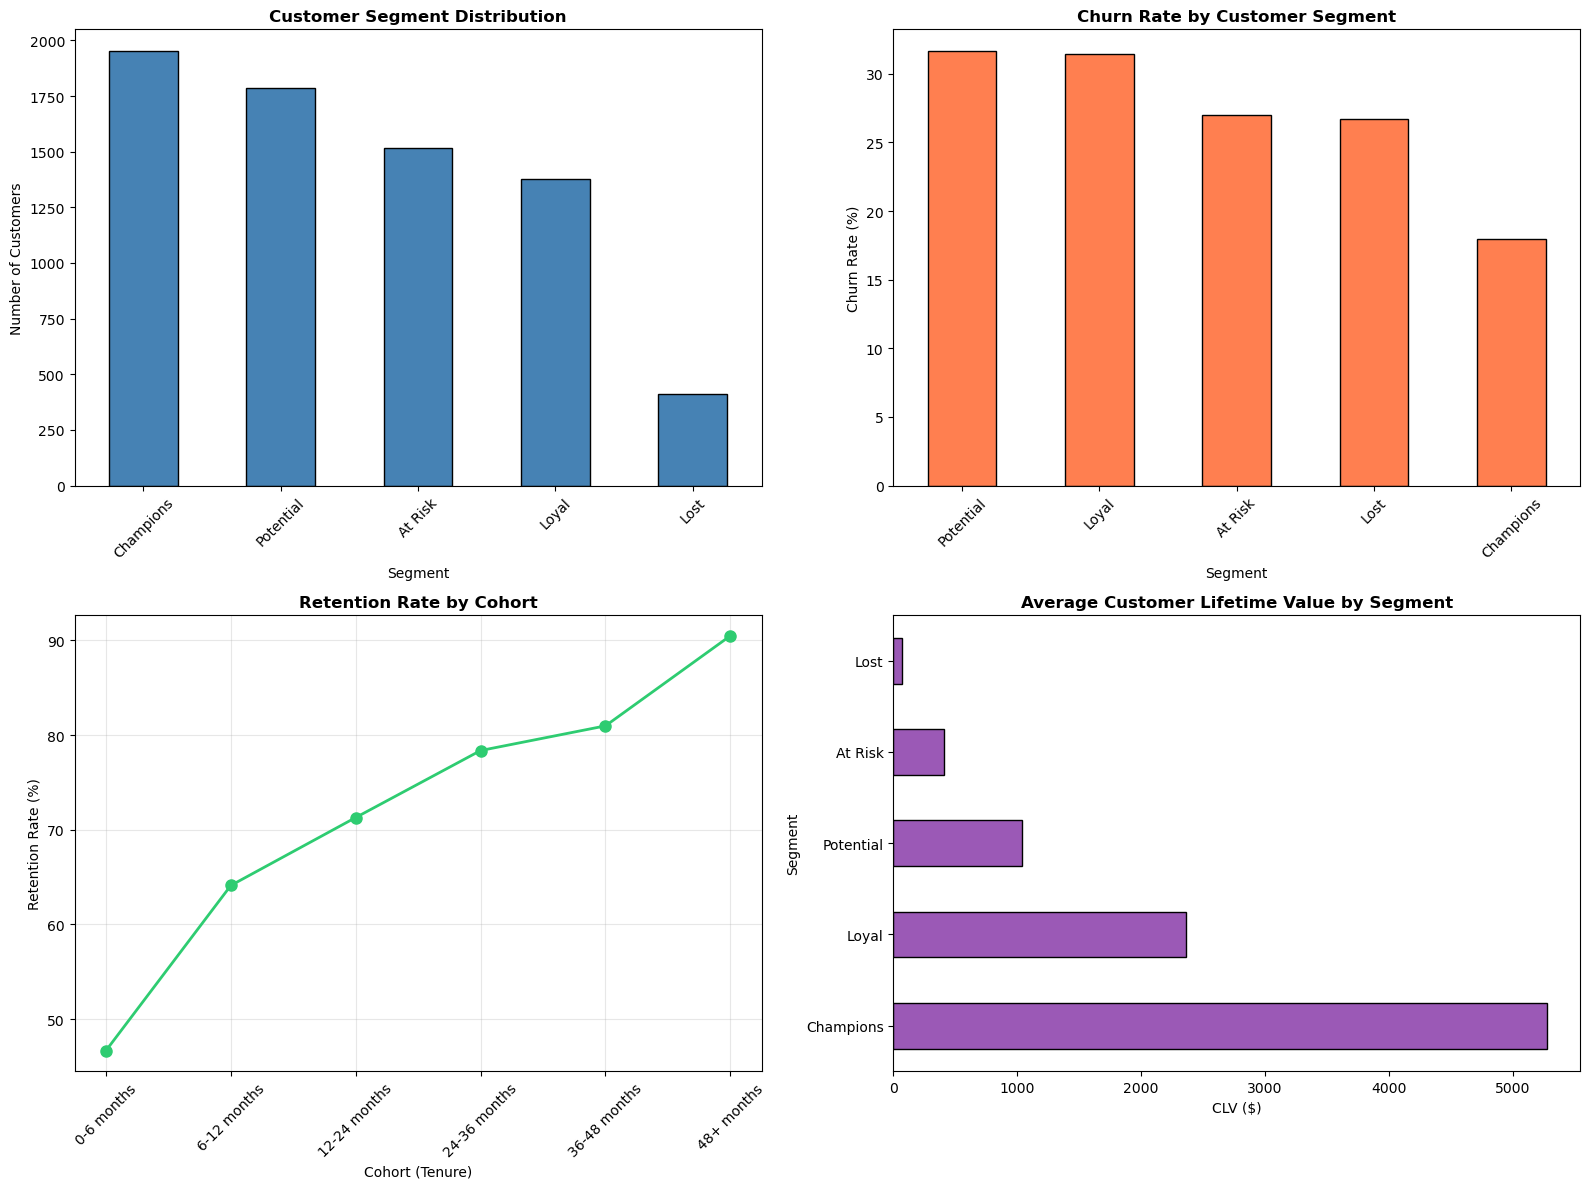

Visualization saved: images/03_segmentation_analysis.png


In [35]:
#Visualize segments and cohorts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Customer Segments Distribution
segment_counts = df['Customer_Segment'].value_counts()
segment_counts.plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Customer Segment Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Segment')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45)

# Plot 2: Churn Rate by Segment
segment_churn.plot(kind='bar', ax=axes[0, 1], color='coral', edgecolor='black')
axes[0, 1].set_title('Churn Rate by Customer Segment', fontweight='bold')
axes[0, 1].set_xlabel('Segment')
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)

# Plot 3: Cohort Retention Rates (FIXED)
x_positions = range(len(cohort_df))
axes[1, 0].plot(x_positions, cohort_df['Retention_Rate'], 
               marker='o', color='#2ecc71', linewidth=2, markersize=8)
axes[1, 0].set_title('Retention Rate by Cohort', fontweight='bold')
axes[1, 0].set_xlabel('Cohort (Tenure)')
axes[1, 0].set_ylabel('Retention Rate (%)')
axes[1, 0].set_xticks(x_positions)
axes[1, 0].set_xticklabels(cohort_df['Cohort'], rotation=45)
axes[1, 0].grid(alpha=0.3)

# Plot 4: CLV by Segment
segment_clv.plot(kind='barh', ax=axes[1, 1], color='#9b59b6', edgecolor='black')
axes[1, 1].set_title('Average Customer Lifetime Value by Segment', fontweight='bold')
axes[1, 1].set_xlabel('CLV ($)')
axes[1, 1].set_ylabel('Segment')

plt.tight_layout()
plt.savefig('images/03_segmentation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved: images/03_segmentation_analysis.png")

In [37]:
#Prepare data for modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("PREPARING DATA FOR CHURN PREDICTION MODEL")

# Create a copy for modeling
df_model = df.copy()

# Encode target variable
df_model['Churn_Binary'] = (df_model['Churn'] == 'Yes').astype(int)

# Select features for model
features_to_use = [
    'tenure', 'MonthlyCharges', 'TotalCharges', 'num_services',
    'Contract', 'PaymentMethod', 'InternetService', 'PaperlessBilling',
    'SeniorCitizen', 'Partner', 'Dependents'
]

# Encode categorical variables
label_encoders = {}
for col in ['Contract', 'PaymentMethod', 'InternetService', 'PaperlessBilling', 'Partner', 'Dependents']:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col + '_encoded'] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le
        features_to_use.remove(col)
        features_to_use.append(col + '_encoded')

# Prepare X and y
X = df_model[features_to_use]
y = df_model['Churn_Binary']

print(f"\nFeatures: {X.shape[1]}")
print(f"Samples: {X.shape[0]:,}")
print(f"Churn rate: {y.mean()*100:.2f}%")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")

PREPARING DATA FOR CHURN PREDICTION MODEL

Features: 11
Samples: 7,043
Churn rate: 26.54%

Train set: 5,634 samples
Test set: 1,409 samples


In [39]:
#Train simple Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("TRAINING CHURN PREDICTION MODEL")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = lr_model.predict(X_test_scaled)
y_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("\nModel Performance:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Calculate business metrics
true_negatives, false_positives, false_negatives, true_positives = cm.ravel()
print(f"\nTrue Positives (Correctly identified churners): {true_positives}")
print(f"False Negatives (Missed churners): {false_negatives}")
print(f"Detection Rate: {true_positives/(true_positives+false_negatives)*100:.1f}%")

TRAINING CHURN PREDICTION MODEL

Model Performance:
              precision    recall  f1-score   support

    Retained       0.91      0.71      0.80      1035
     Churned       0.50      0.81      0.62       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409

ROC-AUC Score: 0.833

Confusion Matrix:
[[731 304]
 [ 72 302]]

True Positives (Correctly identified churners): 302
False Negatives (Missed churners): 72
Detection Rate: 80.7%


In [41]:
#Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 10 Churn Predictors:")
print(feature_importance.head(10).to_string(index=False))

# Save feature importance
feature_importance.to_csv('results/feature_importance.csv', index=False)


Top 10 Churn Predictors:
                 Feature  Coefficient
                  tenure        -1.06
          MonthlyCharges         0.99
        Contract_encoded        -0.68
            num_services        -0.57
            TotalCharges         0.46
PaperlessBilling_encoded         0.22
      Dependents_encoded        -0.13
 InternetService_encoded        -0.11
           SeniorCitizen         0.09
   PaymentMethod_encoded         0.09


In [43]:
#Business impact calculation
print("RETENTION STRATEGY & ROI ANALYSIS")

# Assumptions
retention_campaign_cost = 100  # Cost per targeted customer
retention_success_rate = 0.30  # 30% of targeted customers are saved
avg_customer_lifespan_months = 24  # Average after successful retention

# Calculate potential impact
high_risk_customers = df[df['Customer_Segment'].isin(['At Risk', 'Lost'])].copy()
high_risk_count = len(high_risk_customers)
high_risk_monthly_revenue = high_risk_customers['MonthlyCharges'].sum()

print(f"\n1. HIGH-RISK CUSTOMER ANALYSIS")
print(f"   Customers at risk: {high_risk_count:,}")
print(f"   Monthly revenue at risk: ${high_risk_monthly_revenue:,.2f}")
print(f"   Annual revenue at risk: ${high_risk_monthly_revenue * 12:,.2f}")

# Retention campaign projections
customers_to_target = high_risk_count
campaign_cost = customers_to_target * retention_campaign_cost
customers_saved = int(customers_to_target * retention_success_rate)
avg_saved_customer_revenue = high_risk_monthly_revenue / high_risk_count

revenue_saved = customers_saved * avg_saved_customer_revenue * avg_customer_lifespan_months
roi = ((revenue_saved - campaign_cost) / campaign_cost) * 100

print(f"\n2. RETENTION CAMPAIGN PROJECTIONS")
print(f"   Customers to target: {customers_to_target:,}")
print(f"   Campaign cost: ${campaign_cost:,.2f}")
print(f"   Expected customers saved: {customers_saved:,}")
print(f"   Revenue saved (24 months): ${revenue_saved:,.2f}")
print(f"   Net benefit: ${revenue_saved - campaign_cost:,.2f}")
print(f"   ROI: {roi:.0f}%")

# Save business metrics
business_metrics = {
    'Metric': [
        'Total Customers',
        'Churn Rate',
        'Monthly Revenue Lost',
        'Annual Revenue at Risk',
        'High-Risk Customers',
        'Recommended Campaign Cost',
        'Expected Customers Saved',
        'Projected Revenue Saved (24mo)',
        'ROI'
    ],
    'Value': [
        f"{len(df):,}",
        f"{(df['Churn']=='Yes').sum()/len(df)*100:.1f}%",
        f"${df[df['Churn']=='Yes']['MonthlyCharges'].sum():,.2f}",
        f"${df[df['Churn']=='Yes']['MonthlyCharges'].sum() * 12:,.2f}",
        f"{high_risk_count:,}",
        f"${campaign_cost:,.2f}",
        f"{customers_saved:,}",
        f"${revenue_saved:,.2f}",
        f"{roi:.0f}%"
    ]
}

business_df = pd.DataFrame(business_metrics)
business_df.to_csv('results/business_recommendations.csv', index=False)

print("\n3. RECOMMENDED ACTIONS BY SEGMENT")
print("\nChampions (Low churn risk):")
print("  - Upsell premium services")
print("  - Loyalty rewards program")
print("  - Referral incentives")

print("\nLoyal (Moderate churn risk):")
print("  - Exclusive offers")
print("  - Service bundle upgrades")
print("  - Annual contract incentives")

print("\nPotential (Moderate-High churn risk):")
print("  - Engagement campaigns")
print("  - Service optimization consultations")
print("  - Limited-time upgrade offers")

print("\nAt Risk (High churn risk):")
print("  - Proactive retention calls")
print("  - Custom retention offers (10-15% discount)")
print("  - Contract migration to longer terms")

print("\nLost (Very high churn risk):")
print("  - Win-back campaigns")
print("  - Aggressive discounts (20-25%)")
print("  - Service improvement guarantees")

print("\nBusiness metrics saved to: results/business_recommendations.csv")

RETENTION STRATEGY & ROI ANALYSIS

1. HIGH-RISK CUSTOMER ANALYSIS
   Customers at risk: 1,929
   Monthly revenue at risk: $64,726.50
   Annual revenue at risk: $776,718.00

2. RETENTION CAMPAIGN PROJECTIONS
   Customers to target: 1,929
   Campaign cost: $192,900.00
   Expected customers saved: 578
   Revenue saved (24 months): $465,467.09
   Net benefit: $272,567.09
   ROI: 141%

3. RECOMMENDED ACTIONS BY SEGMENT

Champions (Low churn risk):
  - Upsell premium services
  - Loyalty rewards program
  - Referral incentives

Loyal (Moderate churn risk):
  - Exclusive offers
  - Service bundle upgrades
  - Annual contract incentives

Potential (Moderate-High churn risk):
  - Engagement campaigns
  - Service optimization consultations
  - Limited-time upgrade offers

At Risk (High churn risk):
  - Proactive retention calls
  - Custom retention offers (10-15% discount)
  - Contract migration to longer terms

Lost (Very high churn risk):
  - Win-back campaigns
  - Aggressive discounts (20-25%

In [45]:
#Save model and create dashboard data
import pickle

print("SAVING FINAL OUTPUTS")

# Save model
with open('models/churn_prediction_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved: models/churn_prediction_model.pkl")

# Create dashboard data
dashboard_data = df.copy()
dashboard_data.to_csv('dashboard/churn_dashboard_data.csv', index=False)

print(f"Dashboard data saved: {len(dashboard_data):,} customers")

# Create segment summary for dashboard
segment_summary = df.groupby('Customer_Segment').agg({
    'customerID': 'count',
    'Churn': lambda x: (x == 'Yes').sum() / len(x) * 100,
    'MonthlyCharges': 'mean',
    'CLV': 'mean',
    'tenure': 'mean'
}).round(2)

segment_summary.columns = ['Customer_Count', 'Churn_Rate', 'Avg_Monthly_Revenue', 'Avg_CLV', 'Avg_Tenure']
segment_summary.to_csv('dashboard/segment_summary.csv')

print("Segment summary saved: dashboard/segment_summary.csv")
print("\nProject complete!")

SAVING FINAL OUTPUTS
Model saved: models/churn_prediction_model.pkl
Dashboard data saved: 7,043 customers
Segment summary saved: dashboard/segment_summary.csv

Project complete!
